In [48]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
from sklearn.manifold import ClassicalMDS
from sklearn.manifold import MDS
from sklearn.metrics import euclidean_distances

In [25]:
### read-in data set
df = pd.read_csv('../../data/AirlineDist.csv')
names = df.columns[1:19].tolist()
D = df.iloc[:,1:19].to_numpy()

In [18]:
print(names)

['Beijing', 'Cape Town', 'Hong Kong', 'Honolulu', 'London', 'Melbourne', 'Mexico', 'Montreal', 'Moscow', 'New Delhi', 'New York', 'Paris', 'Rio de Janeiro', 'Rome', 'San Francisco', 'Singapore', 'Stockholm', 'Tokyo']


In [38]:
### run classical MDS 
cmds = ClassicalMDS(n_components=2, metric = 'precomputed')
X_emb = cmds.fit_transform(D)

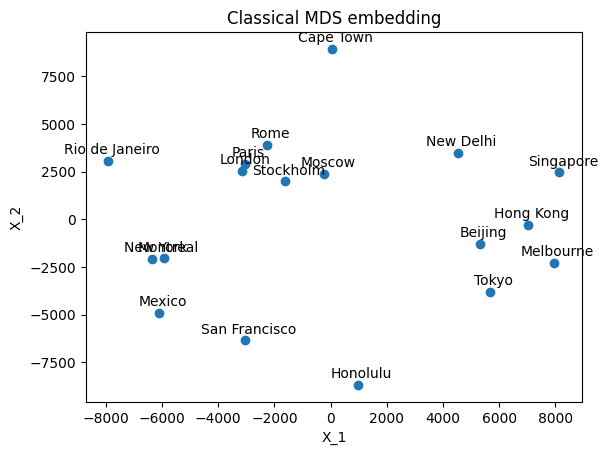

In [39]:
fig, ax = plt.subplots()
ax.scatter(X_emb[:,0], X_emb[:,1])

# Loop to add labels to each point
for i, label in enumerate(names):
    ax.annotate(label, (X_emb[i,0], X_emb[i,1]), textcoords="offset points", xytext=(2.5,5), ha='center')

plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Classical MDS embedding')
plt.show()

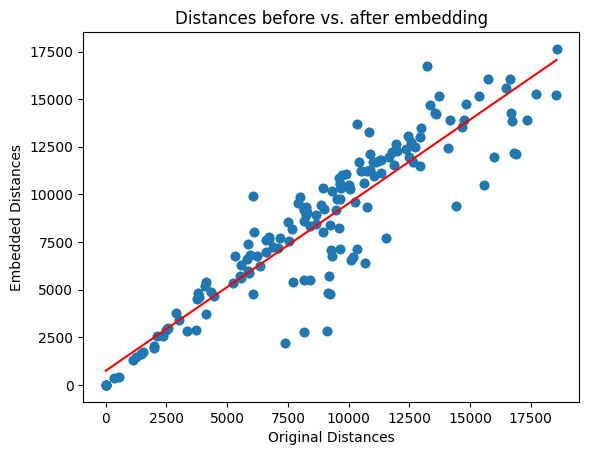

In [52]:
# distances before and after embedding 
D_embedded = euclidean_distances(X_emb)

plt.scatter(D, D_embedded)
plt.plot(np.unique(D), np.poly1d(np.polyfit(D.flatten(), 
         D_embedded.flatten(), 1))(np.unique(D)), color='red')
plt.xlabel('Original Distances')
plt.ylabel('Embedded Distances')
plt.title('Distances before vs. after embedding')
plt.show()

In [37]:
### metric MDS embedding 
metric_mds = MDS(n_components=2, metric = "precomputed", init="classical_mds", normalized_stress=True)
X_emb2 = metric_mds.fit_transform(D)

/Users/martinslawski/Library/Python/3.12/lib/python/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/martinslawski/Library/Python/3.12/lib/python/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 4
  warnings.warn(


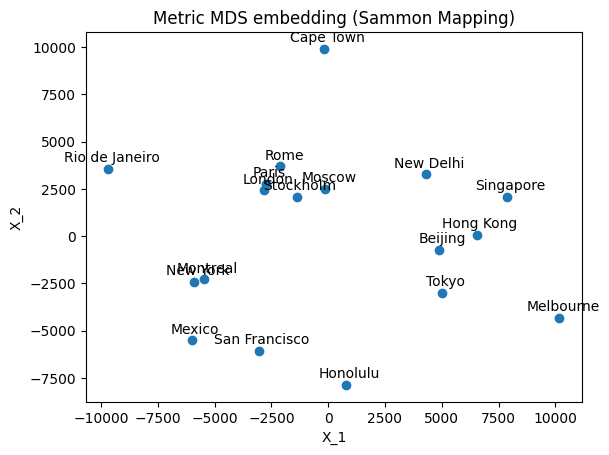

In [40]:
fig, ax = plt.subplots()
ax.scatter(X_emb2[:,0], X_emb2[:,1])

# Loop to add labels to each point
for i, label in enumerate(names):
    ax.annotate(label, (X_emb2[i,0], X_emb2[i,1]), textcoords="offset points", xytext=(2.5,5), ha='center')

plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Metric MDS embedding (Sammon Mapping)')
plt.show()

In [43]:
### non-metric MDS embedding 
nonmetric_mds = MDS(n_components=2, metric_mds = False, metric = "precomputed", init="classical_mds", normalized_stress=True)
X_emb3 = nonmetric_mds.fit_transform(D)

/Users/martinslawski/Library/Python/3.12/lib/python/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/martinslawski/Library/Python/3.12/lib/python/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 4
  warnings.warn(


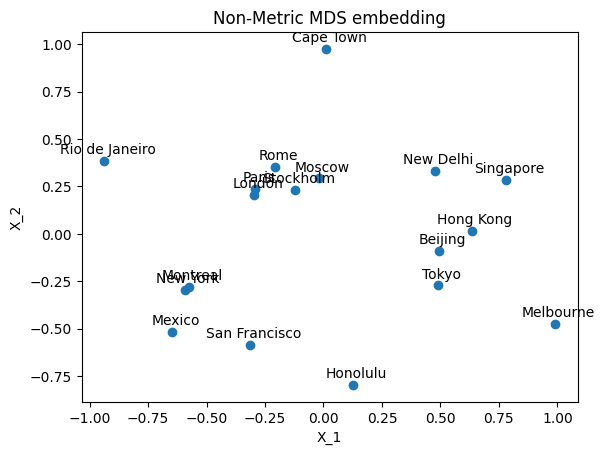

In [42]:
fig, ax = plt.subplots()
ax.scatter(X_emb3[:,0], X_emb3[:,1])

# Loop to add labels to each point
for i, label in enumerate(names):
    ax.annotate(label, (X_emb3[i,0], X_emb3[i,1]), textcoords="offset points", xytext=(2.5,5), ha='center')

plt.xlabel('X_1')
plt.ylabel('X_2')
plt.title('Non-Metric MDS embedding')
plt.show()

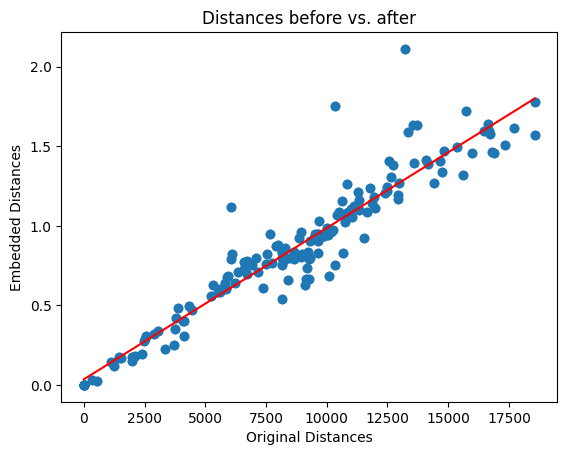

In [53]:
D3_embedded = euclidean_distances(X_emb3)


plt.scatter(D, D3_embedded)
plt.plot(np.unique(D), np.poly1d(np.polyfit(D.flatten(), 
         D3_embedded.flatten(), 1))(np.unique(D)), color='red')
plt.xlabel('Original Distances')
plt.ylabel('Embedded Distances')
plt.title('Distances before vs. after')
plt.show()

In [54]:
ix = np.argsort(D.flatten())

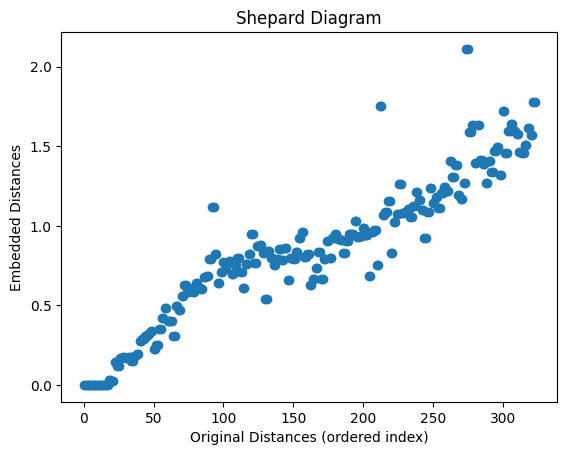

In [61]:
plt.scatter(np.arange(len(ix)), D3_embedded.flatten()[ix])
#plt.plot(np.unique(D), np.poly1d(np.polyfit(D.flatten(), 
#         D3_embedded.flatten(), 1))(np.unique(D)), color='red')
plt.xlabel('Original Distances (ordered index)')
plt.ylabel('Embedded Distances')
plt.title('Shepard Diagram')
plt.show()